# Lesson 2

In [ ]:
!pip install fastbook
import fastbook
from fastbook import *
from fastai.vision.widgets import *

## Add the dataset

In [4]:
import os
from pathlib import Path

os.listdir('/kaggle/input')

# Path to dataset
dataset_path = Path('/kaggle/input/datasets/shreyapmaher/fruits-dataset-images/images')
dataset_path.ls()

[Path('/kaggle/input/datasets/shreyapmaher/fruits-dataset-images/images/apple fruit'), Path('/kaggle/input/datasets/shreyapmaher/fruits-dataset-images/images/orange fruit'), Path('/kaggle/input/datasets/shreyapmaher/fruits-dataset-images/images/strawberry fruit'), Path('/kaggle/input/datasets/shreyapmaher/fruits-dataset-images/images/grapes fruit'), Path('/kaggle/input/datasets/shreyapmaher/fruits-dataset-images/images/banana fruit'), Path('/kaggle/input/datasets/shreyapmaher/fruits-dataset-images/images/cherry fruit'), Path('/kaggle/input/datasets/shreyapmaher/fruits-dataset-images/images/kiwi fruit'), Path('/kaggle/input/datasets/shreyapmaher/fruits-dataset-images/images/mango fruit'), Path('/kaggle/input/datasets/shreyapmaher/fruits-dataset-images/images/chickoo fruit')]

## Define the DataBlock and create DataLoaders

In [7]:
# Define a DataBlock
fruits = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=RandomResizedCrop(224, min_scale=0.5),
    batch_tfms=aug_transforms()
)

# Create DataLoaders
dls = fruits.dataloaders(dataset_path)

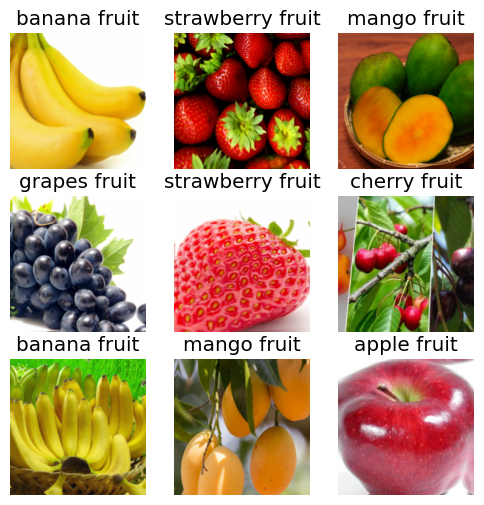

In [8]:
dls.show_batch(max_n=9, figsize=(6,6))

## Train a model

In [10]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(5)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 223MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,3.153551,1.514807,0.541667,00:12


epoch,train_loss,valid_loss,error_rate,time
0,1.765763,0.817803,0.236111,00:10
1,1.257696,0.459267,0.152778,00:11
2,0.938161,0.385147,0.097222,00:11
3,0.754604,0.370786,0.097222,00:11
4,0.636657,0.370055,0.111111,00:10


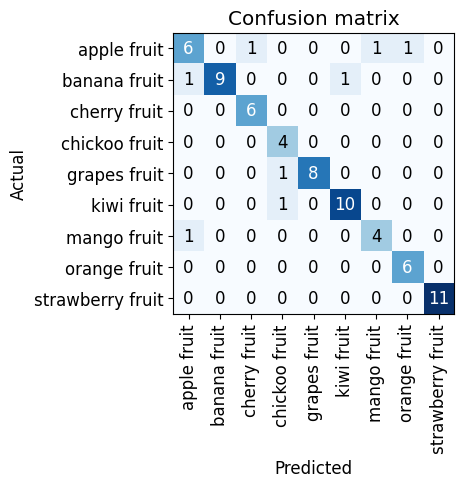

In [11]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

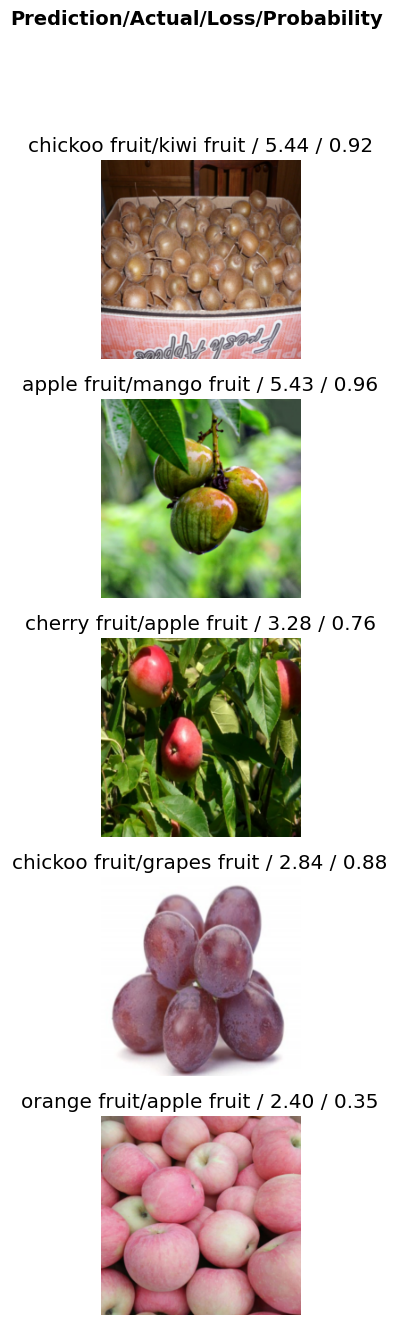

In [15]:
interp.plot_top_losses(5, nrows=5)

## Export the model

In [16]:
learn.export('model.pkl')